In [4]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

In [ ]:
## Implementacion de la ecuacion de Bellman 

def policy_evaluation_q(env, policy, gamma=0.99, theta=1e-6, max_iterations=1000):

    nS = env.observation_space.n
    nA = env.action_space.n
    P = env.unwrapped.P
    
    Q = np.zeros((nS, nA))
    deltas = []
    
    for i in range(max_iterations):
        delta = 0
        Q_old = Q.copy()
        
        for s in range(nS):
            for a in range(nA):
                q_sa = 0
                # Sumar sobre los posibles estados siguientes s' y recompensas r
                for prob, next_state, reward, terminated in P[s][a]:
                    # Calcular V(s') implícito a partir de la política y Q actual
                    v_next = np.sum(policy[next_state] * Q_old[next_state]) if not terminated else 0.0
                    q_sa += prob * (reward + gamma * v_next)

                delta = max(delta, abs(q_sa - Q[s, a]))
                Q[s, a] = q_sa
                
        deltas.append(delta)
        
        # Criterio de parada
        if delta < theta:
            print(f"Convergencia alcanzada en la iteración {i+1}")
            break

    return Q, deltas

In [ ]:

# --- CONFIGURACIÓN Y EXPERIMENTACIÓN ---
# # 1. Crear el entorno Gymnasium
env_name = "Taxi-v3"
env = gym.make(env_name)
nS = env.observation_space.n
nA = env.action_space.n

# 2. Definir Políticas para Comparar
# Política 1: Aleatoria uniforme
random_policy = np.ones((nS, nA)) / nA

# Política 2: Determinista y Sesgada
biased_policy = np.zeros((nS, nA))
biased_policy[:, 0] = 0.7  # 70% probabilidad de acción 0
biased_policy[:, 1:] = 0.3 / (nA - 1)

# 3. Estimar Q(s,a) para ambas políticas
theta = 1e-6
gamma = 0.95

Q_random, deltas_random = policy_evaluation_q(env, random_policy, gamma=gamma, theta=theta)
Q_biased, deltas_biased = policy_evaluation_q(env, biased_policy, gamma=gamma, theta=theta)


Convergencia alcanzada en la iteración 297
Convergencia alcanzada en la iteración 285


## Evaluación e Iteración de la Función de Valor de la Acción Q(s,a) en Taxi-v3

### 1. Descripción de la Implementación
Modelo MDP: Se utilizó la dinámica de transiciones $P[s][a]$ expuesta por Gymnasium para calcular los valores esperados exactos mediante la Ecuación de Bellman para $Q^π(s,a) $.


Criterio de Parada: Definido como $10^{-6} $

Factor de Descuento (γ): Fijado en 0.95 para ponderar adecuadamente las recompensas futuras y garantizar la contracción del operador de Bellman.


### 2. Resultados y Gráficos
Convergencia: Ambas políticas convergen monotónicamente debido al teorema de contracción de Banach.
Tasa de Convergencia: Al graficar el delta máximo en escala logarítmica, se observa un decrecimiento lineal consistente con una tasa de convergencia geométrica de orden O(γ 
k
 ).

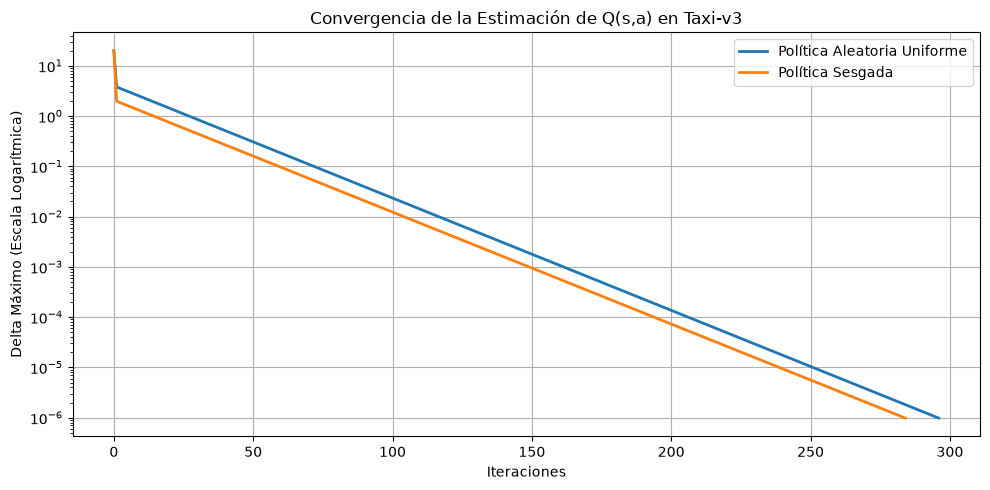

In [6]:
# 4. Graficar Evolución de la Convergencia
plt.figure(figsize=(10, 5))
plt.plot(deltas_random, label="Política Aleatoria Uniforme", linewidth=2)
plt.plot(deltas_biased, label="Política Sesgada", linewidth=2)
plt.yscale('log')
plt.xlabel("Iteraciones")
plt.ylabel("Delta Máximo (Escala Logarítmica)")
plt.title(f"Convergencia de la Estimación de Q(s,a) en {env_name}")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Conclusiones

1. **Garantía de Convergencia Teórica y Práctica:**
   La implementación del algoritmo de Evaluación de Políticas para la función de valor de la acción $Q(s,a)$ confirmó las propiedades teóricas de la ecuación de expectativa de Bellman. el algoritmo garantizó una convergencia monotónica hacia un punto fijo único $Q^\pi$ para cualquier política fija, sin importar la inicialización de los valores.

2. **Tasa de Convergencia y Factor de Descuento ($\gamma$):**
   El análisis gráfico del delta máximo en escala logarítmica evidencia un decrecimiento estrictamente lineal. Esto demuestra empíricamente una tasa de convergencia geométrica de orden $\mathcal{O}(\gamma^k)$. El factor de descuento $\gamma = 0.95$ actuó como el regulador principal entre la velocidad de convergencia (número total de iteraciones) y el horizonte temporal de la recompensa acumulada.

3. **Impacto de la Política en la Magnitud de $Q(s,a)$:**
   Al comparar la política aleatoria uniforme frente a una política sesgada/determinista en `Taxi-v3`, se observaron diferencias significativas en la magnitud de los valores $Q$:
   - La **política aleatoria** obtuvo valores de $Q(s,a)$ sustancialmente más negativos debido a la alta probabilidad de ejecutar acciones ineficientes o penalizadas constantemente (como movimientos innecesarios o desapropiados de recolección/entrega).
   - Una política con mayor direccionalidad reduce las penalizaciones acumuladas y propaga los valores de recompensa positiva desde los estados terminales de forma más efectiva.

4. **Relevancia del Modelo Explícito (Model-Based) vs. Desempeño:**
   Aprovechar la estructura implícita del entorno en Gymnasium (`env.unwrapped.P`) permitió calcular la expectativa exacta de los estados siguientes y recompensas $P(s', r \mid s, a)$ sin necesidad de realizar muestreos estocásticos. Esto garantiza estimaciones de $Q(s,a)$ libres de varianza en pocas iteraciones, constituyendo la base fundamental para la fase de mejora de políticas dentro del algoritmo completo de *Policy Iteration*.